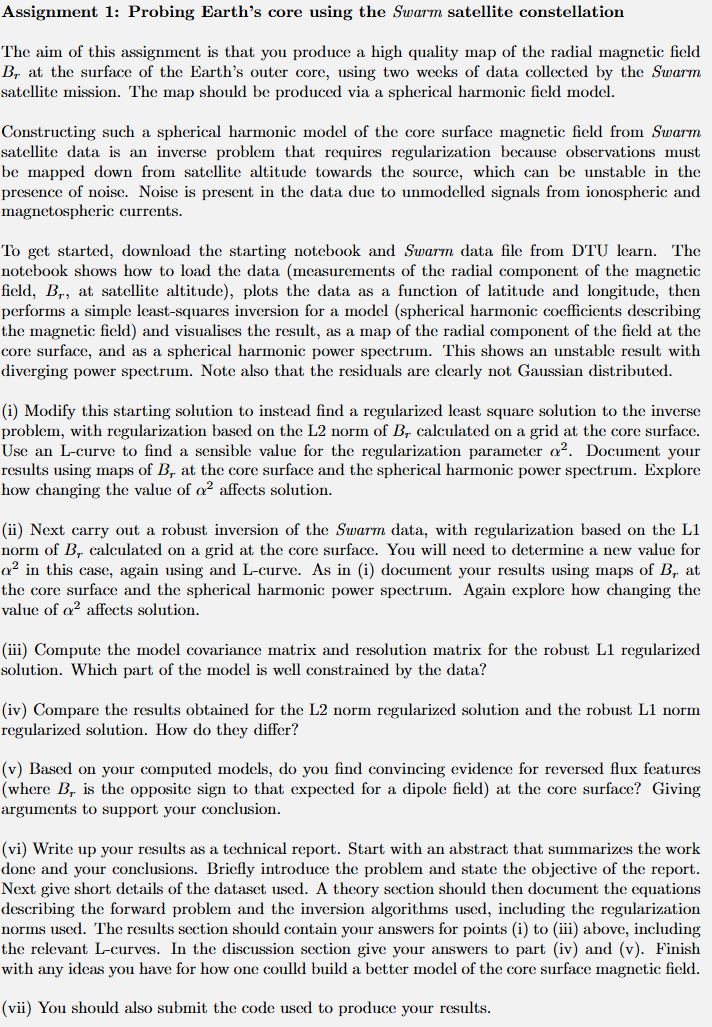

In [1]:
## Starting Notebook for Assignment 1: Robust Estimation and Sparsity regurlarization
## part of "Inverse Probelms and Machine Learning in Earth and Space Physics", MSc Course

import numpy as np
import matplotlib.pyplot as plt
import scipy.io as spio
import cartopy.crs as ccrs
from matplotlib.colorbar import Colorbar
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ChaosMagPy modules
# Install with: pip install chaosmagpy
import chaosmagpy as cp
from chaosmagpy.model_utils import design_gauss

# Constants needed
a=6371.2     # Earth radius in km
c=3480.0       # Core radius in km

# Radius at which to evaluate SH Power spectra
ps_r = c

# CMB plot limits in mT
limit = [-1,1]

# Load Swarm data file located in current directory
data = spio.loadmat("SW_B_14_28_Sept14_selected.mat")
d=data["Br"].reshape(-1,)  # Select radial field data
theta=data["theta"].reshape(-1,)
phi=data["lambda"].reshape(-1,) # lambda is already used by Python, use phi instead
r = data["r"].reshape(-1,)

c:\Users\jeppe\Documents\MEGA\Base\DTU\30760 Inverse Problems and Machine Learning in Earth and Space Physics\.pixi\envs\default\Lib\site-packages\hdf5storage\utilities.py:44: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [2]:
# Global plot with polar areas
def plot_global(lon,lat,data,point_size,title="",cbar_label="",cmap=None,limit=None):
    if limit == None:
        limit = np.max(abs(data))
    else:
        limit = np.max(abs(np.array(limit)))
    # create figure
    fig = plt.figure(figsize=(9, 5))
    # make array of axes
    gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 1], height_ratios=[0.35, 0.65])
    axes = []
    axes.append(plt.subplot(gs[0, 0], projection=ccrs.NearsidePerspective(central_latitude=90.)))
    axes.append(plt.subplot(gs[0, 2], projection=ccrs.NearsidePerspective(central_latitude=-90.)))
    axes.append(plt.subplot(gs[1, :], projection=ccrs.Mollweide()))
    # Iterate over axes
    for ax in axes:
        pc = ax.scatter(lon, lat, c=data, s=point_size, cmap=cmap, vmin=-limit,
                           vmax=limit, transform=ccrs.PlateCarree())
        ax.gridlines(linewidth=0.5,
                     ylocs=np.linspace(-90, 90, num=7),  # parallels
                     xlocs=np.linspace(-180, 180, num=13),
                     color='grey', alpha=0.6, linestyle='-')  # meridians
        ax.coastlines(linewidth=0.5)
    # Add colorbar
    # inset axes into global map and move upwards
    cax = inset_axes(axes[-1], width="55%", height="10%", loc='upper center',
                     borderpad=-9)
    # use last artist for the colorbar
    clb = plt.colorbar(pc, cax=cax, extend='both', orientation='horizontal')
    clb.set_label('{}'.format(cbar_label), fontsize=12)

    #Title
    plt.suptitle("{}".format(title))
    #Adjust plot
    plt.subplots_adjust(top=0.985, bottom=0.015, left=0.008,
                        right=0.992, hspace=0.0, wspace=0.0)
    plt.show()

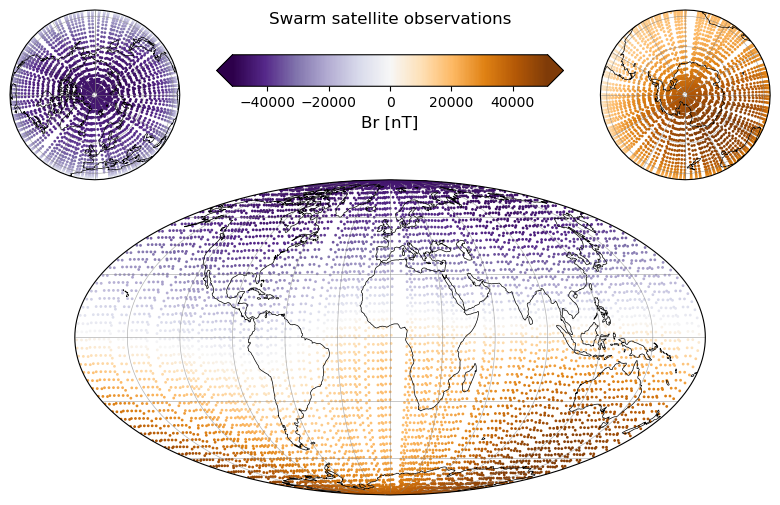

In [3]:
#  Plot simple map of B_r data
point_size = 1
plot_global(phi,90-theta,d,point_size,title="Swarm satellite observations",cbar_label="Br [nT]",cmap=plt.cm.PuOr_r)

In [4]:
# Set SH degree of model
N=20

# Design matrix for B_r at data location
Gr, _, _ = design_gauss(r,theta,phi,N)

# Setup Regularization Matrix
# H_Br_cmb is linear operator matrix H for this problem, produces predictions of
# the radial component of the magnetic field B_r on a grid at the CMB
# L2 norm (m^T H_Br_cmb^T H_Br_cmb m) approximates B_r^2 integrated over the CMB
# L1 norm approximate abs(H_Br_cmb m) integrated over the CMB

# The meshgrid size defines the size of H_Br_cmb, leading to matrices of size H_Br_cmb.shape[0] x H_Br_cmb.shape[0]
# A very fine grid leads to a large memory footprint, so use a grid size you (and your machine) find suitable
# Here are some alternatives with decreasing memory requirements.
#phi_cmb, theta_cmb = np.meshgrid(np.linspace(-179., 179., num=180), np.linspace(1., 179., num=90)) # W_md: 16200x16200
#phi_cmb, theta_cmb = np.meshgrid(np.linspace(-178., 178., num=90), np.linspace(2., 178., num=45)) # W_md: 4050x4050
phi_cmb, theta_cmb = np.meshgrid(np.linspace(-177.5, 177.5, num=70), np.linspace(2.5, 177.5, num=36)) # W_md: 2520 x 2520

phi_cmb = phi_cmb.reshape(-1,)
theta_cmb = theta_cmb.reshape(-1,)
r_cmb = c*np.ones(theta_cmb.shape)

H_Br_cmb, _, _ = design_gauss(r_cmb,theta_cmb,phi_cmb,N)
R=H_Br_cmb.T@H_Br_cmb

In [5]:
# Gr_plot produces predictions of B_r at the CMB on a fine grid suitable for plotting
phi_plot, theta_plot = np.meshgrid(np.linspace(-179., 180., num=360), np.linspace(1., 179., num=180))
phi_plot = phi_plot.reshape(-1,)
theta_plot = theta_plot.reshape(-1,)
r_plot = c*np.ones(theta_plot.shape)

Gr_plot, _, _ = design_gauss(r_plot,theta_plot,phi_plot,N)

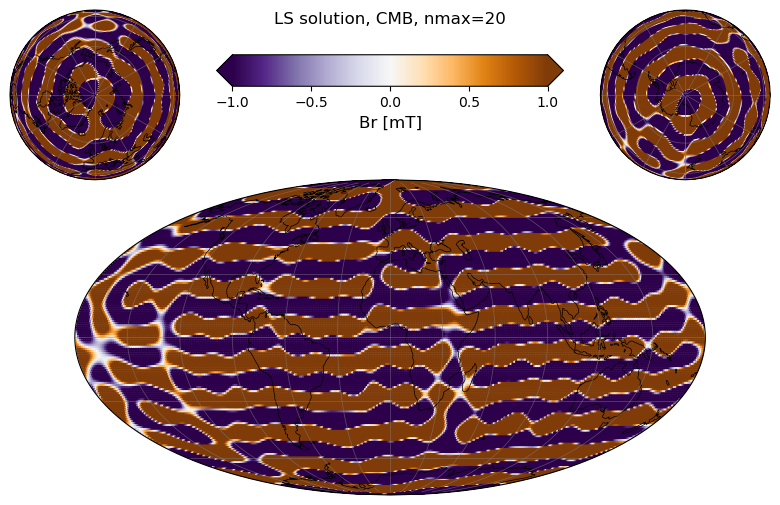

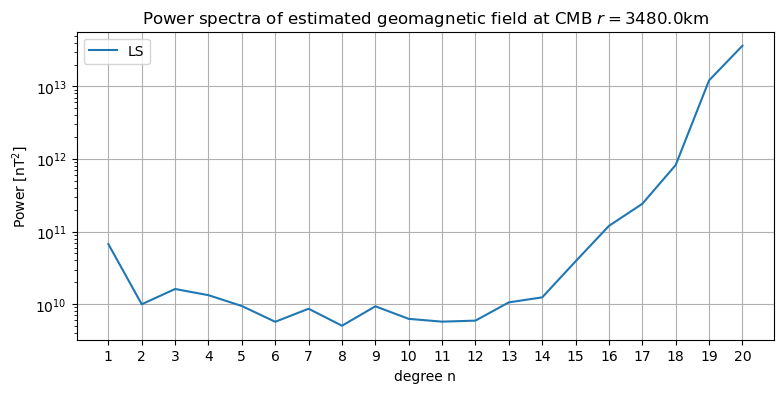

rms misfit: 12.0nT


In [6]:
# Least square inversion
m_ls = np.linalg.solve((Gr.T@Gr),Gr.T@d)

# SH power spectrum and Br on grid at CMB
ps_ls = cp.model_utils.power_spectrum(m_ls,radius=ps_r)
Br_ls = Gr_plot@m_ls

# Plot map of B_r at CMB from least-squares solution (V. Poor: unphysical ringing/instability)
plot_global(phi_plot,90-theta_plot,Br_ls*10**(-6),point_size,
            title="LS solution, CMB, nmax={}".format(N),cbar_label="Br [mT]",cmap=plt.cm.PuOr_r,limit=limit)

# Plot Power spectrum (Unphysical divergence at high SH degree)
n = np.arange(1,N+1)
plt.figure(figsize=(9,4))
plt.semilogy(n,ps_ls,label="LS")
plt.xlabel("degree n")
plt.ylabel(r"Power [nT$^2$]")
plt.title(r"Power spectra of estimated geomagnetic field at CMB $r={}$km".format(ps_r))
nmax = np.max([len(n)])
plt.xticks(np.arange(1,nmax+1))
plt.legend()
plt.grid()
plt.show()

# Residuals
r_ls=d-Gr@m_ls
# rms misfit
rms_resid_ls=np.sqrt(r_ls.T@r_ls/len(d))
print("rms misfit: {:.1f}nT".format(float(rms_resid_ls)))

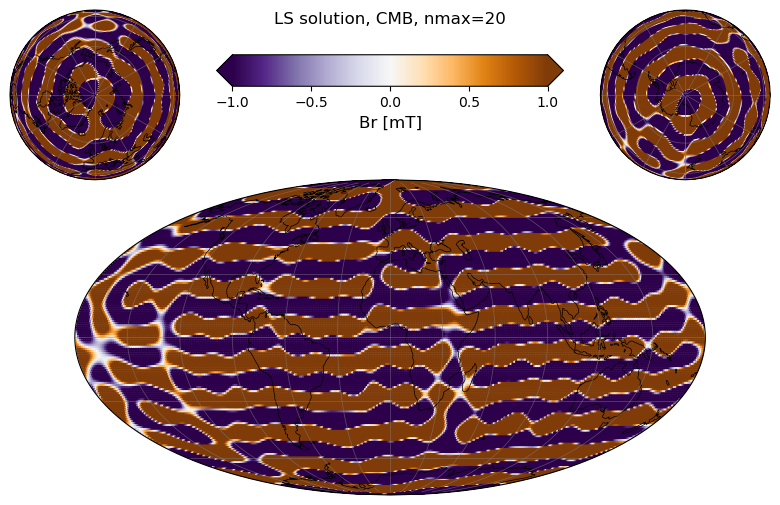

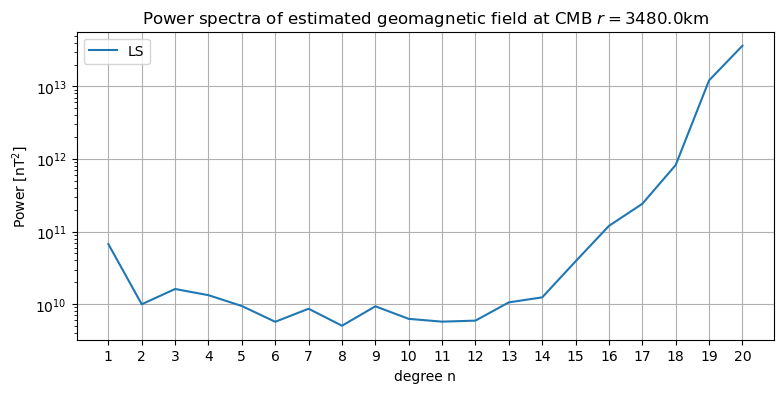

rms misfit: 12.0nT


In [ ]:
# Regularised least squares solution

m_ls = np.linalg.solve((Gr.T@Gr),Gr.T@d)

# SH power spectrum and Br on grid at CMB
ps_ls = cp.model_utils.power_spectrum(m_ls,radius=ps_r)
Br_ls = Gr_plot@m_ls

# Plot map of B_r at CMB from least-squares solution (V. Poor: unphysical ringing/instability)
plot_global(phi_plot,90-theta_plot,Br_ls*10**(-6),point_size,
            title="LS solution, CMB, nmax={}".format(N),cbar_label="Br [mT]",cmap=plt.cm.PuOr_r,limit=limit)

# Plot Power spectrum (Unphysical divergence at high SH degree)
n = np.arange(1,N+1)
plt.figure(figsize=(9,4))
plt.semilogy(n,ps_ls,label="LS")
plt.xlabel("degree n")
plt.ylabel(r"Power [nT$^2$]")
plt.title(r"Power spectra of estimated geomagnetic field at CMB $r={}$km".format(ps_r))
nmax = np.max([len(n)])
plt.xticks(np.arange(1,nmax+1))
plt.legend()
plt.grid()
plt.show()

# Residuals
r_ls=d-Gr@m_ls
# rms misfit
rms_resid_ls=np.sqrt(r_ls.T@r_ls/len(d))
print("rms misfit: {:.1f}nT".format(float(rms_resid_ls)))